<a href="https://colab.research.google.com/github/vishaleswari1813-cpu/CSA0710-CN/blob/main/Title1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (11).zip to archive (11).zip
Saving archive (10).zip to archive (10).zip
Saving archive (8).zip to archive (8).zip
Saving archive (7).zip to archive (7).zip


In [2]:
import zipfile
import os

# Create extraction folder
extract_path = "/content/datasets"
os.makedirs(extract_path, exist_ok=True)

# Extract all uploaded zip files
for file_name in uploaded.keys():
    if file_name.endswith('.zip'):
        with zipfile.ZipFile(file_name, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [3]:
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

/content/datasets/SmartGrid_FL_Final_Dataset.csv
/content/datasets/iot_network_intrusion_data.csv
/content/datasets/synthetic_motor_failure_data.csv
/content/datasets/smart_home_device_usage_data.csv
/content/datasets/README.md
/content/datasets/smart_home_energy_data.csv
/content/datasets/delhi_power_load_dataset1.csv


In [4]:
import os

folder = extract_path

for i, file in enumerate(os.listdir(folder)):
    old_path = os.path.join(folder, file)

    # Skip folders
    if os.path.isfile(old_path):
        new_name = f"dataset_{i+1}.csv"   # Change naming here
        new_path = os.path.join(folder, new_name)
        os.rename(old_path, new_path)

print("Renaming completed!")

Renaming completed!


In [5]:
import pandas as pd

dataframes = {}

for file in os.listdir(folder):
    if file.endswith('.csv'):
        path = os.path.join(folder, file)
        df = pd.read_csv(path)
        dataframes[file] = df

        print(f"\n📊 Preview of {file}")
        print(df.head())


📊 Preview of dataset_1.csv
   Voltage Magnitude (V)  Current Magnitude (A)  Active Power (kW)  \
0             234.967142              10.682532           1.781019   
1             228.617357              14.843983           2.853301   
2             236.476885              15.090084           3.487762   
3             245.230299              17.363152           3.488460   
4             227.658466               8.165708           1.649813   

   Reactive Power (kVAR)  Load Demand (kW)  Frequency Variation (Hz)  \
0               1.768698        207.241301                 -0.386505   
1               1.837155        367.335041                 -0.321152   
2               0.754583        291.810987                 -0.280525   
3               2.441508        261.160226                  0.325702   
4               0.856721        280.096045                 -0.044261   

   Power Factor  Energy Consumption (kWh)  Temperature Value (°C)  \
0      0.709557                643.291221        

ParserError: Error tokenizing data. C error: Expected 1 fields in line 6, saw 3


In [6]:
import pandas as pd
import os

dataframes = {}

for file in os.listdir(folder):
    if file.endswith('.csv'):
        path = os.path.join(folder, file)

        try:
            # Try normal read
            df = pd.read_csv(path)

        except:
            try:
                # Try with different separator (semicolon)
                df = pd.read_csv(path, sep=';')

            except:
                try:
                    # Try with tab separator
                    df = pd.read_csv(path, sep='\t')

                except:
                    # अंतिम fallback (ignore bad lines)
                    df = pd.read_csv(path, on_bad_lines='skip', engine='python')

        dataframes[file] = df

        print(f"\n📊 Preview of {file}")
        print(df.head())


📊 Preview of dataset_1.csv
   Voltage Magnitude (V)  Current Magnitude (A)  Active Power (kW)  \
0             234.967142              10.682532           1.781019   
1             228.617357              14.843983           2.853301   
2             236.476885              15.090084           3.487762   
3             245.230299              17.363152           3.488460   
4             227.658466               8.165708           1.649813   

   Reactive Power (kVAR)  Load Demand (kW)  Frequency Variation (Hz)  \
0               1.768698        207.241301                 -0.386505   
1               1.837155        367.335041                 -0.321152   
2               0.754583        291.810987                 -0.280525   
3               2.441508        261.160226                  0.325702   
4               0.856721        280.096045                 -0.044261   

   Power Factor  Energy Consumption (kWh)  Temperature Value (°C)  \
0      0.709557                643.291221        

In [7]:
cleaned_data = {}

for name, df in dataframes.items():
    print(f"\n🧹 Cleaning: {name}")

    # Remove completely empty rows
    df = df.dropna(how='all')

    # Remove duplicate rows
    df = df.drop_duplicates()

    # Strip column names
    df.columns = df.columns.str.strip()

    # Try converting object columns to numeric where possible
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')

    cleaned_data[name] = df

    print("✅ Cleaned Shape:", df.shape)


🧹 Cleaning: dataset_1.csv
✅ Cleaned Shape: (4000, 22)

🧹 Cleaning: dataset_2.csv
✅ Cleaned Shape: (10000, 6)

🧹 Cleaning: dataset_6.csv
✅ Cleaned Shape: (144000, 4)

🧹 Cleaning: dataset_4.csv
✅ Cleaned Shape: (6000, 13)

🧹 Cleaning: dataset_3.csv
✅ Cleaned Shape: (5000, 5)

🧹 Cleaning: dataset_5.csv
✅ Cleaned Shape: (53, 1)

🧹 Cleaning: dataset_7.csv
✅ Cleaned Shape: (8737, 14)


/tmp/ipykernel_5780/4172243937.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/tmp/ipykernel_5780/4172243937.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/tmp/ipykernel_5780/4172243937.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/tmp/ipykernel_5780/4172243937.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignor

In [8]:
for name, df in cleaned_data.items():
    for col in df.columns:
        if 'time' in col.lower() or 'date' in col.lower():
            try:
                df[col] = pd.to_datetime(df[col])
                df = df.sort_values(by=col)
                df.set_index(col, inplace=True)
                print(f"⏱ Time column set for {name}: {col}")
            except:
                pass

    cleaned_data[name] = df

⏱ Time column set for dataset_1.csv: Timestamp
⏱ Time column set for dataset_2.csv: Timestamp
⏱ Time column set for dataset_6.csv: Time_Min
⏱ Time column set for dataset_3.csv: Timestamp
⏱ Time column set for dataset_7.csv: Date
⏱ Time column set for dataset_7.csv: Time


/tmp/ipykernel_5780/1454646390.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])
/tmp/ipykernel_5780/1454646390.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])


In [9]:
for name, df in cleaned_data.items():
    print(f"\n📊 Dataset: {name}")
    print(df.info())
    print(df.describe())


📊 Dataset: dataset_1.csv
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4000 entries, 2025-01-01 00:00:00 to 2025-06-16 15:00:00
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Voltage Magnitude (V)       4000 non-null   float64
 1   Current Magnitude (A)       4000 non-null   float64
 2   Active Power (kW)           4000 non-null   float64
 3   Reactive Power (kVAR)       4000 non-null   float64
 4   Load Demand (kW)            4000 non-null   float64
 5   Frequency Variation (Hz)    4000 non-null   float64
 6   Power Factor                4000 non-null   float64
 7   Energy Consumption (kWh)    4000 non-null   float64
 8   Temperature Value (°C)      4000 non-null   float64
 9   Humidity Level (%)          4000 non-null   float64
 10  Wind Speed (m/s)            4000 non-null   float64
 11  Solar Irradiance (W/m²)     4000 non-null   float64
 12  Location Index              

In [10]:
for name, df in cleaned_data.items():
    print(f"\n🔍 Handling Missing Values: {name}")

    # Forward fill (best for time series)
    df = df.fillna(method='ffill')

    # If still missing, backward fill
    df = df.fillna(method='bfill')

    cleaned_data[name] = df

    print("Remaining nulls:\n", df.isnull().sum())


🔍 Handling Missing Values: dataset_1.csv
Remaining nulls:
 Voltage Magnitude (V)         0
Current Magnitude (A)         0
Active Power (kW)             0
Reactive Power (kVAR)         0
Load Demand (kW)              0
Frequency Variation (Hz)      0
Power Factor                  0
Energy Consumption (kWh)      0
Temperature Value (°C)        0
Humidity Level (%)            0
Wind Speed (m/s)              0
Solar Irradiance (W/m²)       0
Location Index                0
Grid Stability Index          0
Voltage Deviation             0
Line Loss (kW)                0
Current Imbalance (%)         0
Renewable Contribution (%)    0
Client ID                     0
Grid Status                   0
Fault Severity                0
dtype: int64

🔍 Handling Missing Values: dataset_2.csv
Remaining nulls:
 Source_IP          0
Protocol           0
Packet_Type        0
Payload_Bytes      0
Label_Is_Attack    0
dtype: int64

🔍 Handling Missing Values: dataset_6.csv
Remaining nulls:
 House_ID         

/tmp/ipykernel_5780/2812986254.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipykernel_5780/2812986254.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')



📈 Plotting: dataset_1.csv


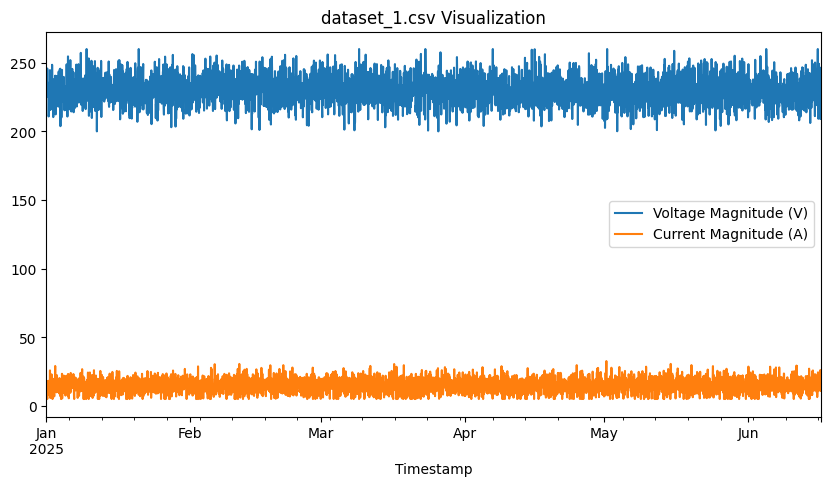


📈 Plotting: dataset_2.csv


TypeError: no numeric data to plot

In [11]:
import matplotlib.pyplot as plt

for name, df in cleaned_data.items():
    print(f"\n📈 Plotting: {name}")

    # Plot first 2 columns (avoid overload)
    df.iloc[:, :2].plot(figsize=(10,5))
    plt.title(f"{name} Visualization")
    plt.show()


📈 Plotting: dataset_1.csv


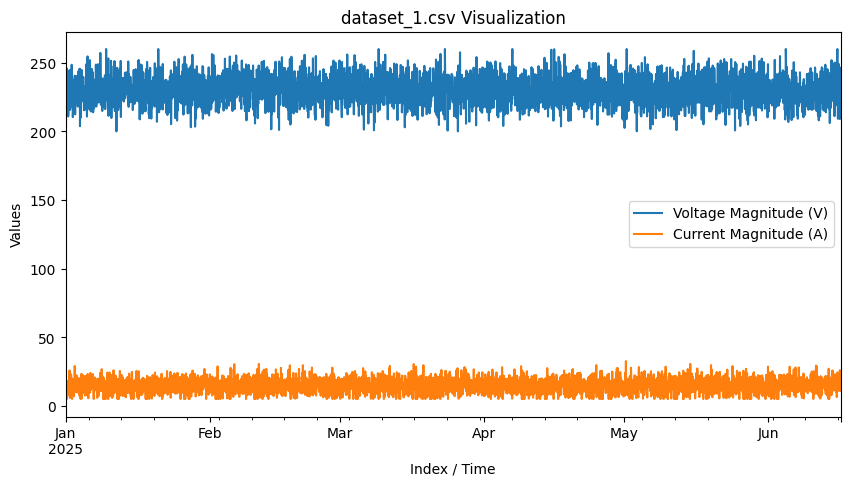


📈 Plotting: dataset_2.csv


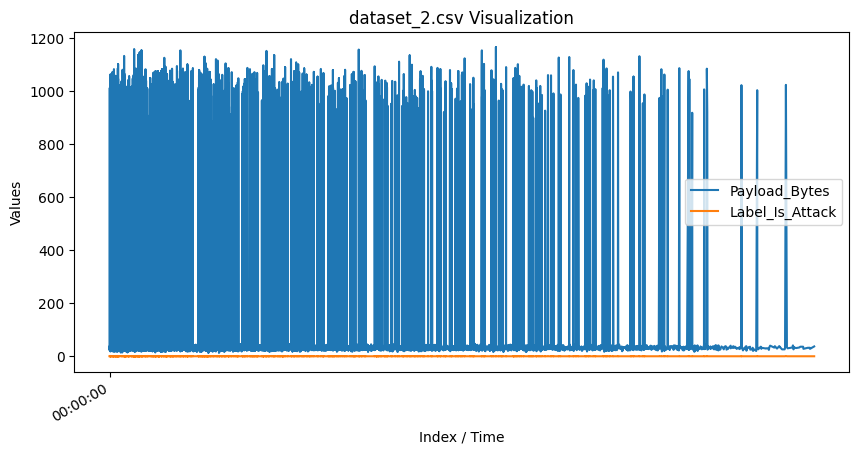


📈 Plotting: dataset_6.csv


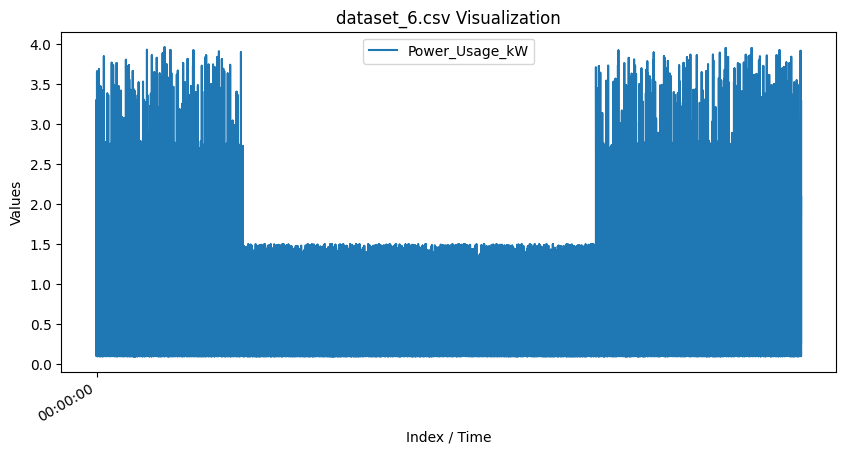


📈 Plotting: dataset_4.csv


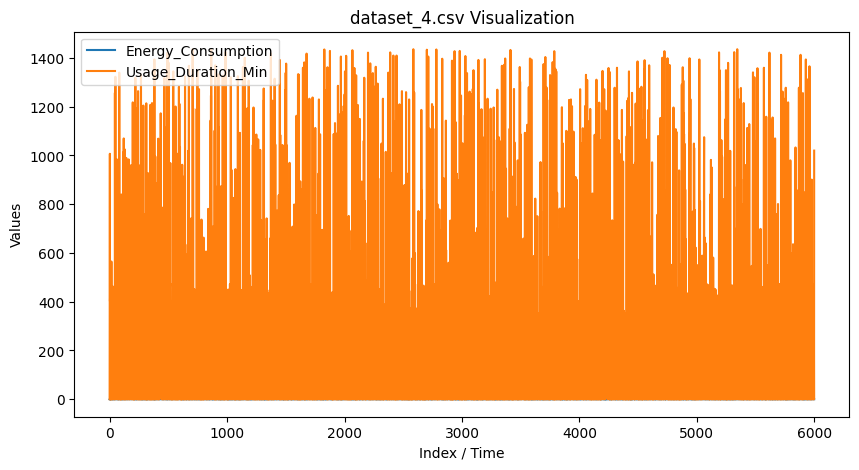


📈 Plotting: dataset_3.csv


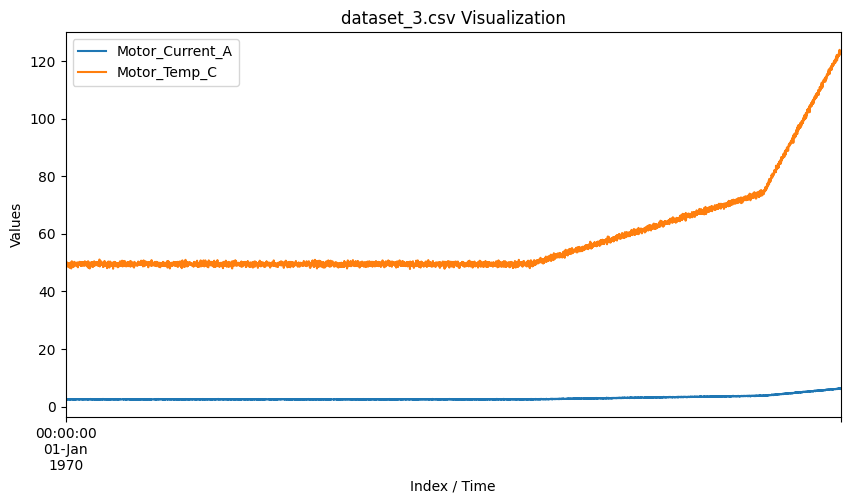


📈 Plotting: dataset_5.csv
⚠ No numeric data to plot in this dataset

📈 Plotting: dataset_7.csv


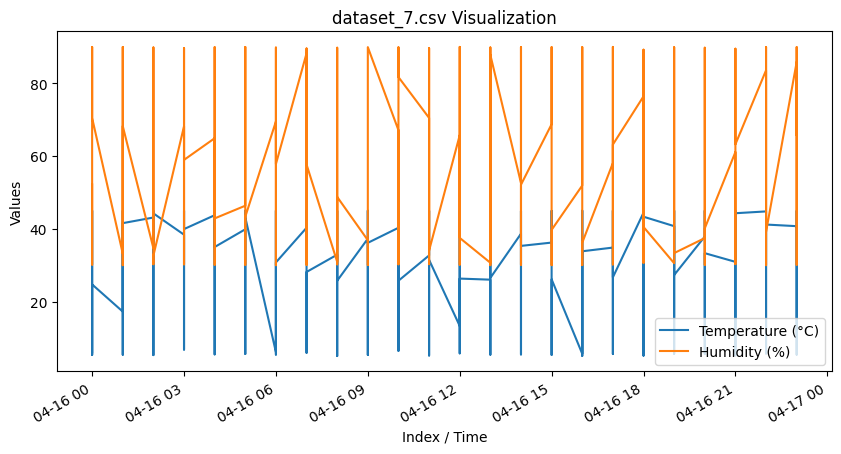

In [12]:
import matplotlib.pyplot as plt

for name, df in cleaned_data.items():
    print(f"\n📈 Plotting: {name}")

    # Select only numeric columns
    numeric_df = df.select_dtypes(include=['number'])

    if numeric_df.shape[1] == 0:
        print("⚠ No numeric data to plot in this dataset")
        continue

    # Plot first 2 numeric columns
    numeric_df.iloc[:, :2].plot(figsize=(10,5))

    plt.title(f"{name} Visualization")
    plt.xlabel("Index / Time")
    plt.ylabel("Values")
    plt.show()

In [13]:
target_data = {}

for name, df in cleaned_data.items():
    numeric_df = df.select_dtypes(include=['number'])

    if numeric_df.shape[1] == 0:
        print(f"⚠ Skipping {name} (no numeric data)")
        continue

    # Select first numeric column as target
    target_col = numeric_df.columns[0]

    ts = numeric_df[[target_col]].copy()
    ts.columns = ['value']   # standard name

    target_data[name] = ts

    print(f"✅ Selected target for {name}: {target_col}")

✅ Selected target for dataset_1.csv: Voltage Magnitude (V)
✅ Selected target for dataset_2.csv: Payload_Bytes
✅ Selected target for dataset_6.csv: Power_Usage_kW
✅ Selected target for dataset_4.csv: Energy_Consumption
✅ Selected target for dataset_3.csv: Motor_Current_A
⚠ Skipping dataset_5.csv (no numeric data)
✅ Selected target for dataset_7.csv: Temperature (°C)


In [14]:
train_test_data = {}

for name, df in target_data.items():
    split = int(len(df) * 0.8)

    train = df.iloc[:split]
    test = df.iloc[split:]

    train_test_data[name] = (train, test)

    print(f"\n{name}")
    print("Train size:", train.shape)
    print("Test size:", test.shape)


dataset_1.csv
Train size: (3200, 1)
Test size: (800, 1)

dataset_2.csv
Train size: (8000, 1)
Test size: (2000, 1)

dataset_6.csv
Train size: (115200, 1)
Test size: (28800, 1)

dataset_4.csv
Train size: (4800, 1)
Test size: (1200, 1)

dataset_3.csv
Train size: (4000, 1)
Test size: (1000, 1)

dataset_7.csv
Train size: (6989, 1)
Test size: (1748, 1)


In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_results = {}

for name, (train, test) in train_test_data.items():
    print(f"\n⚙ Training SARIMA for {name}")

    try:
        model = SARIMAX(train['value'],
                        order=(1,1,1),
                        seasonal_order=(1,1,1,12))  # can tune later

        model_fit = model.fit(disp=False)

        forecast = model_fit.forecast(steps=len(test))

        sarima_results[name] = (test, forecast)

        print("✅ Model trained successfully")

    except Exception as e:
        print(f"❌ Error in {name}: {e}")


⚙ Training SARIMA for dataset_1.csv


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


✅ Model trained successfully

⚙ Training SARIMA for dataset_2.csv


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/

✅ Model trained successfully

⚙ Training SARIMA for dataset_6.csv


...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)


✅ Model trained successfully

⚙ Training SARIMA for dataset_7.csv


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


✅ Model trained successfully


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

for name, (test, forecast) in sarima_results.items():
    mae = mean_absolute_error(test['value'], forecast)
    rmse = np.sqrt(mean_squared_error(test['value'], forecast))

    print(f"\n📊 Results for {name}")
    print("MAE :", mae)
    print("RMSE:", rmse)


📊 Results for dataset_1.csv
MAE : 8.334905057332483
RMSE: 10.338360384377411

📊 Results for dataset_2.csv
MAE : 99.7745118753502
RMSE: 225.24459255856235

📊 Results for dataset_6.csv
MAE : 0.9477049868999361
RMSE: 0.990682283843844

📊 Results for dataset_4.csv
MAE : 0.5928181236197956
RMSE: 1.4713853153983

📊 Results for dataset_3.csv
MAE : 0.5915188246392754
RMSE: 0.9154477236059962

📊 Results for dataset_7.csv
MAE : 6.732072799021407
RMSE: 8.68694188464174


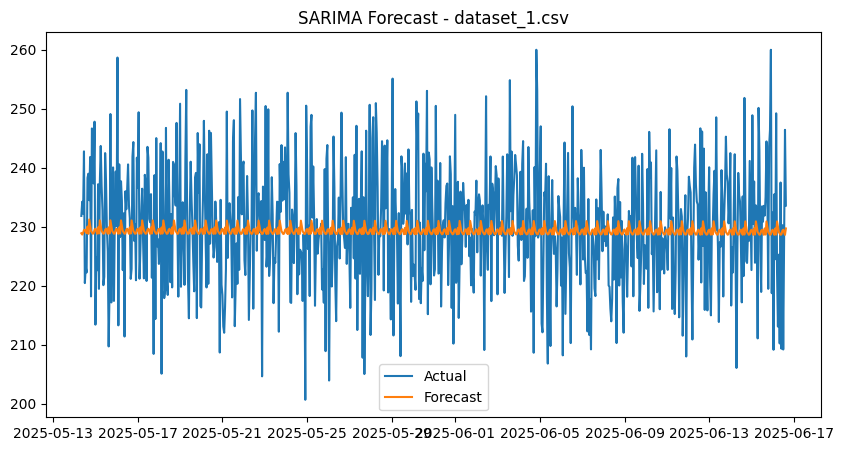

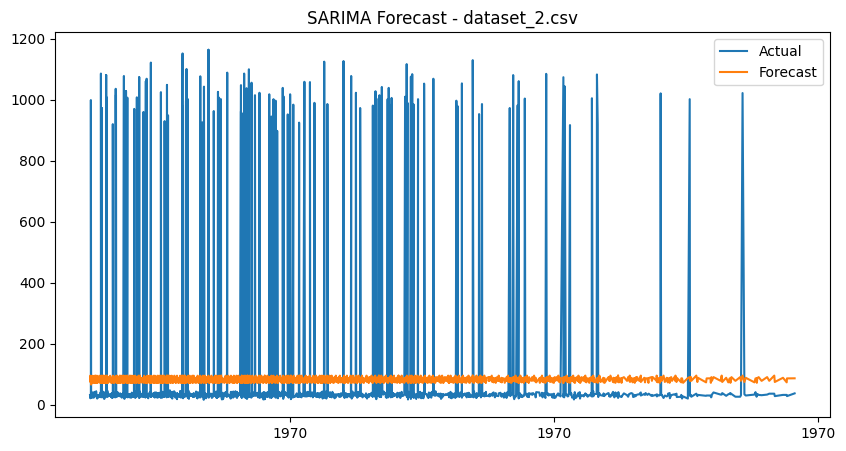

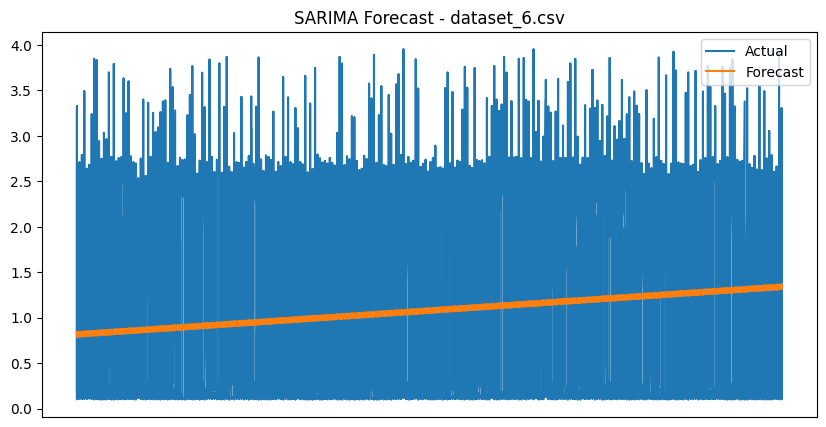

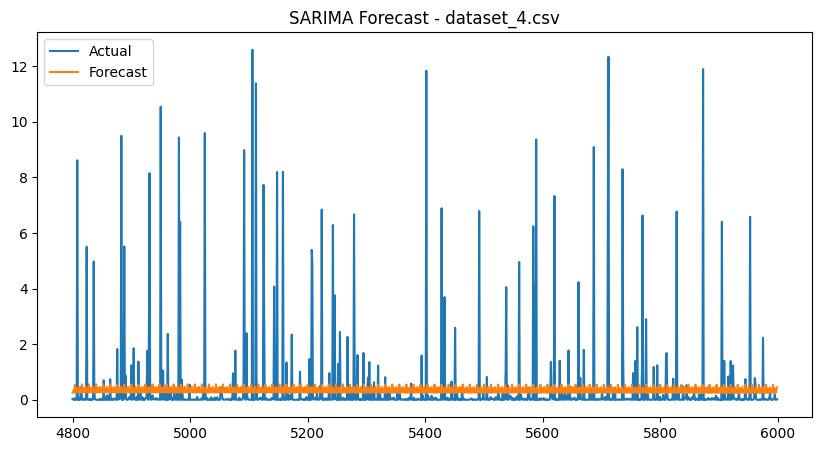

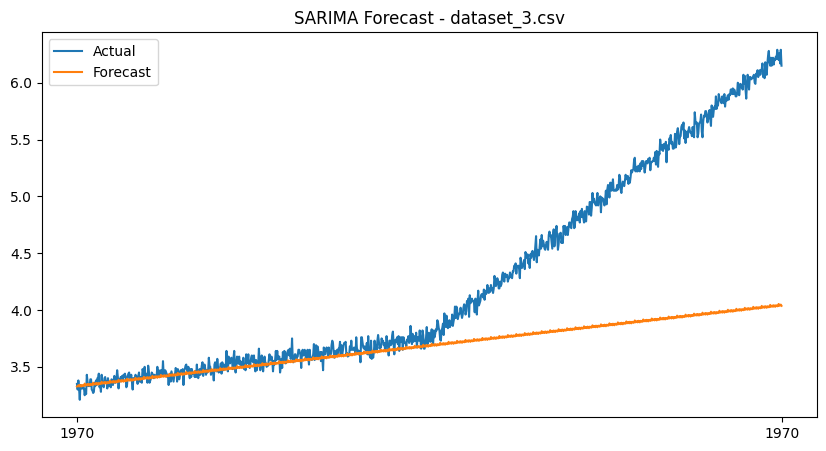

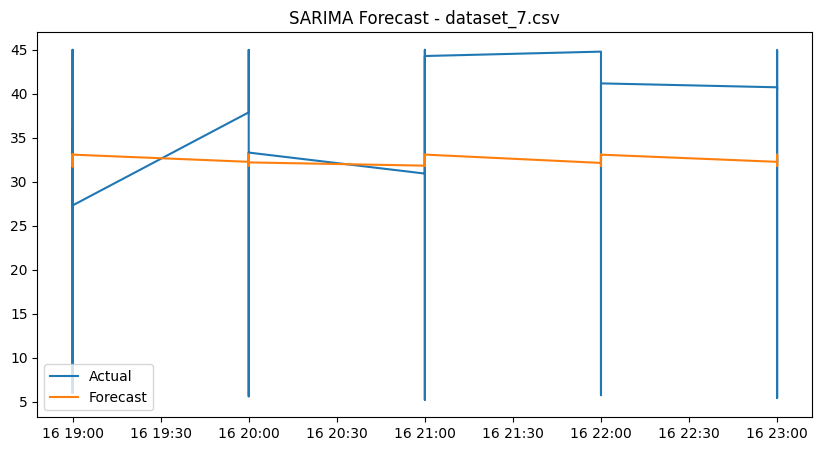

In [17]:
import matplotlib.pyplot as plt

for name, (test, forecast) in sarima_results.items():
    plt.figure(figsize=(10,5))

    plt.plot(test.index, test['value'], label='Actual')
    plt.plot(test.index, forecast, label='Forecast')

    plt.title(f"SARIMA Forecast - {name}")
    plt.legend()
    plt.show()

In [18]:
output_path = "/content/results"
os.makedirs(output_path, exist_ok=True)

for name, (test, forecast) in sarima_results.items():
    result_df = test.copy()
    result_df['forecast'] = forecast.values

    result_df.to_csv(f"{output_path}/{name}_sarima_results.csv")

print("✅ Results saved!")

✅ Results saved!
